# Прогноз оттока клиентов

In [2]:
# Загрузим все необходимые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import xgboost as xgb
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Отключим предупреждения Python, чтобы не захламлять лишним выводом Блокнот
warnings.filterwarnings('ignore')

## Загрузка и подготовка данных

In [4]:
# Скачиваем файл
!wget https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/refs/heads/master/WA_Fn-UseC_-Telco-Customer-Churn.csv

--2026-05-15 02:13:47--  https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/refs/heads/master/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 970457 (948K) [text/plain]
Saving to: ‘WA_Fn-UseC_-Telco-Customer-Churn.csv’

WA_Fn-UseC_-Telco-C 100%[===================>] 947.71K  --.-KB/s    in 0.04s   

2026-05-15 02:13:47 (22.9 MB/s) - ‘WA_Fn-UseC_-Telco-Customer-Churn.csv’ saved [970457/970457]



In [5]:
# Загружаем файл в DataFrame
df = pd.read_csv("./WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head() # Выводим первые 5 записей

# Проверяем основные характеристики данных
print(df.shape)
df.info()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

## Очистка данных

In [6]:
# Преобразуем TotalCharges в число (бывают пустые строки)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Удаляем строки с пропусками
df.dropna(subset=['TotalCharges'], inplace=True)

# Преобразуем целевую переменную: Yes в 1 (ушёл), No в 0 (остался)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Удаляем customerID — он не влияет на отток
df.drop('customerID', axis=1, inplace=True)

## Визуализируем распределение классов

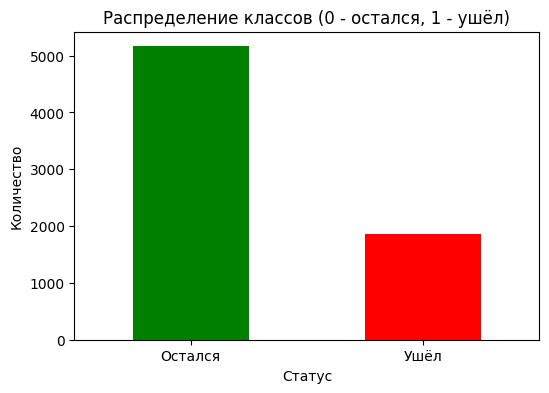

Распределение классов:
Churn
0    5163
1    1869
Name: count, dtype: int64
Доля ушедших: 26.58%


In [30]:
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Распределение классов (0 - остался, 1 - ушёл)')
plt.xlabel('Статус')
plt.ylabel('Количество')
plt.xticks([0, 1], ['Остался', 'Ушёл'], rotation=0)

# Сохраняем график
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')

plt.show()


print("Распределение классов:")
print(df['Churn'].value_counts())
print(f"Доля ушедших: {df['Churn'].mean():.2%}")

## Кодирование категориальных признаков

In [8]:
# Применяем one-hot encoding ко всем категориальным колонкам
df = pd.get_dummies(df, drop_first=True)

## Подготовка признаков и целевой переменной

In [9]:
# Целевая переменная - столбец 'Churn'
X = df.drop('Churn', axis=1)
y = df['Churn']

# Нормализация числовых признаков
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print(f"\nРазмер матрицы признаков X: {X.shape}")
print(f"Размер целевой переменной y: {y.shape}")


Размер матрицы признаков X: (7032, 30)
Размер целевой переменной y: (7032,)


In [10]:
# Разделение на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # сохраняем пропорцию классов
)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]} записей")
print(f"Размер тестовой выборки: {X_test.shape[0]} записей")


Размер обучающей выборки: 5625 записей
Размер тестовой выборки: 1407 записей


In [11]:
# Обучение модели XGBoost
model = xgb.XGBClassifier(
    n_estimators=200,      # количество деревьев
    learning_rate=0.05,    # скорость обучения
    max_depth=3,           # максимальная глубина дерева
    random_state=42,
    use_label_encoder=False,  # отключаем предупреждение о лейблах
    eval_metric='logloss'     # метрика для оценки
)

# Обучаем модель
model.fit(X_train, y_train)

print("\nМодель XGBoost обучена")


Модель XGBoost обучена


In [12]:
# Предсказание и оценка качества
y_pred = model.predict(X_test)

# Вычисляем точность
accuracy = accuracy_score(y_test, y_pred)

print(f"Точность модели на тестовой выборке: {accuracy * 100:.2f}%")

# Выводим детальный отчет
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Остался', 'Ушёл']))

Точность модели на тестовой выборке: 79.60%

Classification Report:

              precision    recall  f1-score   support

     Остался       0.84      0.89      0.86      1033
        Ушёл       0.64      0.54      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



## Матрица ошибок

In [13]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(conf_matrix)

# Создаем подписи для осей
labels = ['Остался', 'Ушёл']

# Строим тепловую карту
fig = px.imshow(
    conf_matrix,
    text_auto=True,
    x=labels,
    y=labels,
    labels=dict(x="Предсказание модели", y="Реальное значение", color="Количество"),
    color_continuous_scale='Blues',
    title=f"Матрица ошибок - XGBoost (Точность: {accuracy:.2%})"
)

fig.update_layout(width=600, height=500)
fig.show()

Матрица ошибок:
[[919 114]
 [173 201]]


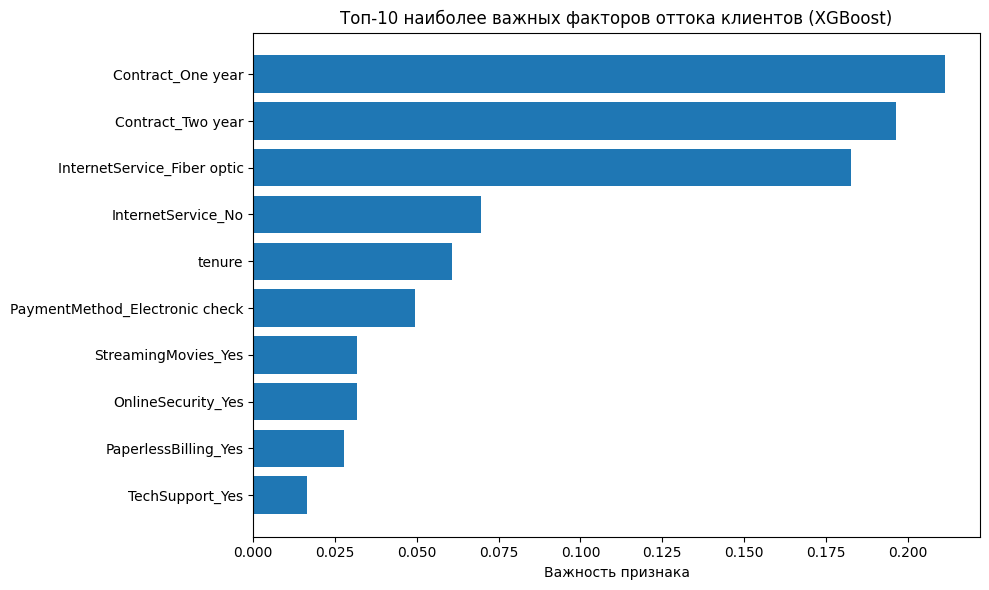

In [31]:
# Получаем важность признаков из модели
feature_importance = model.feature_importances_
features = X.columns

# Сортируем по убыванию важности
sorted_idx = np.argsort(feature_importance)[::-1]

# Визуализируем топ-10 наиболее важных признаков
plt.figure(figsize=(10, 6))
plt.barh(range(10), feature_importance[sorted_idx[:10]], align='center')
plt.yticks(range(10), [features[i] for i in sorted_idx[:10]])
plt.xlabel('Важность признака')
plt.title('Топ-10 наиболее важных факторов оттока клиентов (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()

# Сохраняем график
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')

plt.show()

## Анализ направления влияния признаков на отток

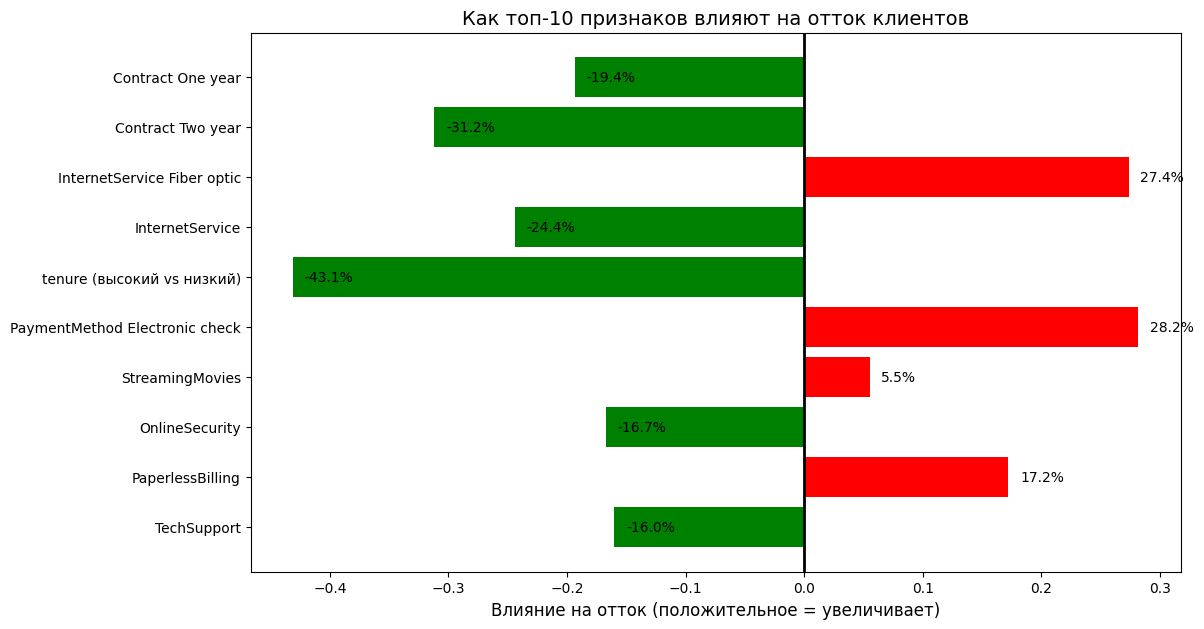

In [32]:
# Собираем данные для графика
diff_data = []
names_data = []
feature_types = []  # запоминаем тип признака

# Берем топ-10 самых важных признаков
top_features = [features[i] for i in sorted_idx[:10]]

for feat in top_features:
    # Проверяем, числовой ли признак
    if feat in numerical_cols:
        # Для числовых признаков: сравниваем верхние 25% vs нижние 25%
        feature_types.append('числовой')
        high_val = y[X[feat] > X[feat].quantile(0.75)].mean()  # высокие значения
        low_val = y[X[feat] < X[feat].quantile(0.25)].mean()   # низкие значения
        diff = high_val - low_val
        clean_name = feat
        # Добавляем пометку в название
        names_data.append(f"{clean_name} (высокий vs низкий)")
    else:
        # Для категориальных признаков: сравниваем 1 vs 0
        feature_types.append('категориальный')
        churn_when_1 = y[X[feat] == 1].mean()
        churn_when_0 = y[X[feat] == 0].mean()
        diff = churn_when_1 - churn_when_0
        clean_name = feat.replace('_Yes', '').replace('_No', '').replace('_', ' ')
        names_data.append(clean_name)

    diff_data.append(diff)

# Строим горизонтальный график
plt.figure(figsize=(12, 7))
colors = ['red' if d > 0 else 'green' for d in diff_data]
bars = plt.barh(names_data, diff_data, color=colors)

plt.axvline(x=0, color='black', linewidth=2, linestyle='-')
plt.xlabel('Влияние на отток (положительное = увеличивает)', fontsize=12)
plt.title('Как топ-10 признаков влияют на отток клиентов', fontsize=14)
plt.gca().invert_yaxis()

# Добавляем подписи на планки
for bar, diff in zip(bars, diff_data):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{diff:.1%}', va='center', fontsize=10)

# Сохраняем график
plt.savefig('churn_influence.png', dpi=150, bbox_inches='tight')

plt.show()

## Выводы

**1. Качество модели**
- Точность модели: 79.60%
- Модель хорошо предсказывает остающихся клиентов (89%), но хуже распознаёт уходящих (54%)

**2. Самые важные признаки (что влияет на отток)**

**Защищают от оттока (зелёные на графике):**
- tenure (стаж) - чем дольше клиент с компанией, тем реже уходит
- Contract One year (Contract Two year) - контракт на 1 и 2 года сильно снижает отток
- InternetService_No - клиенты без интернета уходят реже
- TechSupport - техподдержка помогает удерживать клиента

**Увеличивают отток (красные на графике):**
- PaymentMethod Electronic check - электронные чеки ведут к уходу клиента
- InternetService Fiber optic - оптоволокно приводит к высокому оттоку клиентов
- PaperlessBilling - безбумажные счета увеличивают отток клиентов
- OnlineSecurity - клиенты с онлайн-безопасностью уходят чаще

**3. Что делать бизнесу**
- Переводить клиентов с помесячного контракта на годовой/двухгодичный
- Проверить качество или стоимость оптоволоконного интернета по сравнению с конкурентами
- Удерживать новых клиентов в первые 3-6 месяцев
- Пересмотреть политику электронных чеков и безбумажных счетов